# Setting up a latent function Gaussian Process for H(z)

In [1]:
# import set 
using Turing
using Distances
using LinearAlgebra
using LimberJack
using Interpolations
using GaussianProcess
using Plots
using QuadGK
using BlockDiagonals
using CSV
using DataFrames
using PrettyTables
import LimberJack.TkEisHu
using NumericalIntegration

### Collate data

In [2]:
# setting a cosmology for the fake data, all fiducial cosmo parameters 
cosmo1 = Cosmology();
rd_red = 147.05;

# assumed parameter distributions
omegam_dist = Normal(0.3,0.2);
h0_dist = Uniform(0.5,0.8);
s8_dist = Normal(0.8,0.5);
rd_dist = Normal(147,5);

#### Generate fake data

In [3]:
# hz data
function data_hz()
    z = [
        0.07, 0.09, 0.12, 0.17, 0.179, 0.199, 0.2,
        0.27, 0.28, 0.352, 0.38, 0.3802, 0.4,
        0.4004, 0.4247, 0.44, 0.4497, 0.47, 0.4783,
        0.48, 0.51, 0.593, 0.6, 0.61, 0.68, 0.73,
        0.781, 0.875, 0.88, 0.9, 1.037, 1.3,
        1.363, 1.43, 1.53, 1.75, 1.965
    ]

    data = [
        69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9,
        77.0, 88.8, 83.0, 81.5, 83.0, 95.0, 77.0,
        87.1, 82.6, 92.8, 89.0, 80.9, 97.0, 90.4,
        104.0, 87.9, 97.3, 92.0, 97.3, 105.0,
        125.0, 90.0, 117.0, 154.0, 168.0, 160.0,
        177.0, 140.0, 202.0, 186.5
    ]

    err = [
        19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6,
        14.0, 36.6, 14.0, 1.9, 13.5, 17.0, 10.2,
        11.2, 7.8, 12.9, 23.0, 9.0, 62.0, 1.9,
        13.0, 6.1, 2.1, 8.0, 7.0, 12.0, 17.0,
        40.0, 23.0, 20.0, 17.0, 33.6, 18.0,
        14.0, 40.0, 50.4
    ]

    cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end

    return (
        data_name = "data_hz",
        z = z,
        data = data,
        err = err,
        cov = cov
    )
end
# fs8 data
function data_fs8()

z  = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]

data  = [0.37784, 0.515897, 0.48384, 0.422208, 0.37468, 0.435]

fs8_upper = [0.4723, 0.572693, 0.539136, 0.470586, 0.418064, 0.48]
fs8_lower = [0.28338, 0.449635, 0.428544, 0.378228, 0.343128, 0.39]
err_up = fs8_upper .- data
err_low = data .- fs8_lower
err = (fs8_upper .- fs8_lower) ./ 2

cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end
    
    return (data_name = "data_fs8", z = z, data = data, err = err, cov = cov)
end
# m data
function data_m()

z  = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]

data  = [-0.031370, 0.027840, 0.046650, -0.024690, 0.059960, 0.064550]

err = data ./ 10

cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end
    
    return (data_name = "data_m", z = z, data = data, err = err, cov = cov)
end

data_m (generic function with 1 method)

In [4]:
datam = data_m();
datafs8 = data_fs8();

In [5]:
# correlation matrix
function cov_to_cor(covariance)
    std_devs = sqrt.(diag(covariance))
    return covariance ./ (std_devs * std_devs')
end

cov_to_cor (generic function with 1 method)

In [6]:
function data_DESI()
    # DESI data
    z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
    z = repeat(z1, inner = 3)
    data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
    data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508]
    data_fs8 = [0.37784, 0.515897, 0.48384, 0.422208, 0.37468, 0.435]
    #data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
    
    data = 
    [7.788174, 3.053800, 0.37784,   # BGS (z=0.30)
    12.514437, 1.637266, 0.515897, # LRG1 (z=0.51)
    15.675560, 1.165867, 0.48384,  # LRG2 (z=0.71)
    19.676985, 0.844996, 0.422208, # LRG3 (z=0.92)
    23.861806, 0.470709, 0.37468,  # ELG2 (z=1.32)
    25.708520, 0.426508, 0.435  ]   # QSO (z=1.49)

    # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
    # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
    # Source: arXiv:2411.12021 Appendix A
    C_total = zeros(18, 18);

    # BGS z=0.30
    C_total[1:3, 1:3] = 1e-4 * [
        1314.664401 -142.669742  109.427163;
        -142.669742  829.170940 -158.101737;
        109.427163 -158.101737   88.510877
    ]

    # LRG1 z=0.51
    C_total[4:6, 4:6] = 1e-4 * [
        541.309833   48.425593   -4.652853;
        48.425593   97.249820  -34.923265;
        -4.652853  -34.923265   41.295470
    ]

    # LRG2 z=0.71
    C_total[7:9, 7:9] = 1e-4 * [
        762.457717   39.781004   -1.896006;
        39.781004   36.344098  -17.341350;
        -1.896006  -17.341350   28.119682
    ]

    # LRG3 z=0.92
    C_total[10:12, 10:12] = 1e-4 * [
        847.499793   26.038900    3.257324;
        26.038900   16.251088  -10.044074;
        3.257324  -10.044074   22.370314
    ]

    # ELG2 z=1.32
    C_total[13:15, 13:15] = 1e-4 * [
    2342.506886   26.159601   13.521001;
        26.159601   10.309303   -6.654663;
        13.521001   -6.654663   13.997473
    ]

    # QSO z=1.49
    C_total[16:18, 16:18] = 1e-4 * [
    3013.788566   -2.205101   36.332110;
        -2.205101    5.845806   -6.747133;
        36.332110   -6.747133   19.785658
    ]

    full_covariance = cov_to_cor(C_total);

    cov_final = C_total
    for k in 1:6
        cov_final[3*k,3*k] = datafs8.cov[k,k]
    end

    for h in 1:6
        cov_final[(3*h)-2,3*h] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-2,(3*h)-2]) * full_covariance[(3*h)-2,3*h]
        cov_final[(3*h)-1,3*h] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-1,(3*h)-1]) * full_covariance[(3*h)-1,3*h]
        cov_final[3*h,(3*h)-2] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-2,(3*h)-2]) * full_covariance[(3*h)-2,3*h]
        cov_final[3*h,(3*h)-1] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-1,(3*h)-1]) * full_covariance[(3*h)-1,3*h]
    end
    
    cov = cov_final
    
    err_arr = sqrt.(diag(cov))
    err_dvrd = err_arr[1:3:end]
    err_dhdm = err_arr[2:3:end]
    err_fs8 = err_arr[3:3:end]

    return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fs8 = data_fs8, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fs8 = err_fs8, cov = cov)
end

data_DESI (generic function with 1 method)

In [7]:
dataDESI = data_DESI();
datahz = data_hz();

#### Putting data together

In [8]:
# errors
hz_err = datahz.err;
aiso_err = dataDESI.err_dvrd;
aap_err = dataDESI.err_dhdm;
fs8_err = dataDESI.err_fs8;
m_err = datam.err;

### Functions for hz, dv/rd, dh/dm, fs8, mu

In [9]:
# outputs are arrays, not interpolators
function hz_from_ez(zarr, h0, ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())
    hz = ez_itp(zarr) .* (h0*100)
    return hz
end

function dm_from_ez(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    return chis
end

dm_from_ez (generic function with 1 method)

In [10]:
function fs8_from_ez(zarr, Ωm, σ8, h0, ez)

    T = typeof(Ωm)   # enforce parameter type

    ez_itp1 = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    E(a) = ez_itp1(one(T) ./ a .- one(T))
    Omega_m_a(a) = (Ωm / a^3) / E(a)^2

    function growth_system(a, y)
        D, y1 = y
        dD_da = y1 / (a^3 * E(a))
        dy1_da = (T(1.5)) * a * E(a) * Omega_m_a(a) * D
        return (dD_da, dy1_da)   # tuple is better than vector
    end

    function solve_growth_rk4(a_init::T, a_end::T, n_steps::Int) where T

        da = (a_end - a_init) / T(n_steps)

        a_vals = collect(range(a_init, a_end; length=n_steps+1))
        D_vals = zeros(T, n_steps + 1)
        y1_vals = zeros(T, n_steps + 1)

        D_vals[1] = a_init
        y1_vals[1] = a_init^3 * E(a_init) * one(T)

        for i in 1:n_steps
            a = a_vals[i]
            y = (D_vals[i], y1_vals[i])

            k1 = growth_system(a, y)
            k2 = growth_system(a + da/2, (y[1] + da*k1[1]/2, y[2] + da*k1[2]/2))
            k3 = growth_system(a + da/2, (y[1] + da*k2[1]/2, y[2] + da*k2[2]/2))
            k4 = growth_system(a + da,   (y[1] + da*k3[1],   y[2] + da*k3[2]))

            D_vals[i+1] =
                y[1] + da*(k1[1] + 2k2[1] + 2k3[1] + k4[1]) / T(6)

            y1_vals[i+1] =
                y[2] + da*(k1[2] + 2k2[2] + 2k3[2] + k4[2]) / T(6)
        end

        return a_vals, D_vals, y1_vals
    end

    # IMPORTANT: use parameter type here
    a_init = T(1e-3)
    a_end  = one(T)

    n_steps = 1000

    a_raw, D_raw, y1_raw = solve_growth_rk4(a_init, a_end, n_steps)

    D_today = D_raw[end]
    D_norm = D_raw ./ D_today

    f_raw = y1_raw ./ (a_raw.^2 .* E.(a_raw) .* D_raw)

    fs8_raw = f_raw .* (σ8 .* D_norm)

    a_plot = one(T) ./ (one(T) .+ zarr)

    fs8_itp = LinearInterpolation(a_raw, fs8_raw, extrapolation_bc=Line())
    Dz_itp = LinearInterpolation(a_raw, D_raw, extrapolation_bc=Line())
    fs8z = fs8_itp.(a_plot)
    Dz = Dz_itp.(a_plot) ./ D_today

    return Dz, fs8z
end

fs8_from_ez (generic function with 1 method)

In [11]:
"""
    m_shapefit(cosmo, k, k_pivot, Tk_EH_fid)

ShapeFit slope parameter m (Eq. 5.16 of arXiv:2404.07269).

d/d(ln k) of ln[(P_EH/P_prim) / (P_EH_fid/P_prim_fid)] evaluated at k_pivot.

- `k`          : wavenumbers in h Mpc⁻¹  (log-uniformly spaced, e.g. cosmo.settings.ks)
- `k_pivot`    : pivot scale in h Mpc⁻¹  (≈ 0.03 h Mpc⁻¹)
- `Tk_EH_fid`  : T²_EH(k) at fiducial cosmology (from TkEisHu)
"""
function m_shapefit(
    z, 
    zarr,
    cosmo      :: Cosmology,
    cosmo_fid  :: Cosmology,
    ez         :: Vector{Float64},
    ez_fid     :: Vector{Float64},
    k          :: Vector{Float64},
    k_pivot    :: Float64 = 0.03
)
# seek clarification on arguments of Pk_pri and PL_nw - in paper the argument is just kp

    Dz_array = fs8_from_ez(zarr, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez)[1]
    growth_func = LinearInterpolation(zarr, Dz_array, extrapolation_bc=Line())
    Dz_array_fid = fs8_from_ez(zarr, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez_fid)[1]
    growth_func_fid = LinearInterpolation(zarr, Dz_array_fid, extrapolation_bc=Line())
    
    cpar      = cosmo.cpar
    cpar_fid = cosmo_fid.cpar
    Pk_pri    = @. cpar.As * (k / k_pivot)^(cpar.ns - 1)
    Pk_pri_fid = @. cpar_fid.As * (k / k_pivot)^(cpar_fid.ns - 1)
    Tk_EH     = LimberJack.TkEisHu(cpar, k ./ cpar.h)
    Tk_EH_fid = LimberJack.TkEisHu(cosmo_fid.cpar, k ./ cosmo_fid.cpar.h)
    Dz        = growth_func(z)
    Dz_fid   = growth_func_fid(z)
    # Dz        = LimberJack.growth_factor(cosmo, z)
    # Dz_fid   = LimberJack.growth_factor(cosmo_fid, z)
    log_ratio = @. log((Dz.^2 .* Tk_EH)) - log((Dz_fid.^2 .* Tk_EH_fid))
    # cubic_spline_interpolation requires an AbstractRange for the knots
    lnk = range(log(k[1]), log(k[end]), length = length(k))
    itp = cubic_spline_interpolation(lnk, log_ratio, extrapolation_bc = Line())
    δ = 1e-5
    return (itp(log(k_pivot) + δ) - itp(log(k_pivot) - δ)) / (2δ)
end

m_shapefit

In [12]:
# Utility: drag-epoch sound horizon from the EH fitting formula (same as inside TkEisHu).
# Returns r_d in Mpc.
function r_drag_EH(cpar::CosmoPar)
    wm = cpar.Ωm * cpar.h^2
    wb = cpar.Ωb * cpar.h^2
    keq    = (7.46e-2) * wm / (cpar.h * cpar.θCMB^2)   # Mpc⁻¹
    zeq    = (2.5e4)   * wm * (cpar.θCMB^-4)
    b1     = 0.313 * (wm^-0.419) * (1 + 0.607 * wm^0.674)
    b2     = 0.238 * wm^0.223
    zd     = 1291 * ((wm^0.251) / (1 + 0.659 * wm^0.828)) * (1 + b1 * wb^b2)
    R_pref = 31.5 * wb * (cpar.θCMB^-4)
    Rd     = R_pref * ((zd + 1) / 1e3)^-1
    Req    = R_pref * (zeq    / 1e3)^-1
    rs = sqrt(1 + Rd) + sqrt(Rd + Req)
    rs /= (1 + sqrt(Req))
    rs  = log(rs)
    rs *= (2 / (3 * keq)) * sqrt(6 / Req)
    return rs  # Mpc
end

r_drag_EH (generic function with 1 method)

In [13]:
"""
    sigma_s8_shapefit(fs8, m, A_sp, r_d_fid, h_fid; a_sf)

Step 2: apply the ShapeFit modification (Eq. 5.14 of arXiv:2404.07269;
Eq. 4.10 of arXiv:2411.12021) to a standard f σ_8 value, producing f σ_{s8}.

σ_{s8} = σ_8^{ref} · A^{1/2} · exp[ m/(2a) · tanh(a · ln(r_d^{ref}[h_fid⁻¹ Mpc] / (8 h_fid⁻¹ Mpc))) ]

Step 1 (computing the plain f σ_8^{ref} that feeds this) is just
`cosmo_fid.fs8z(z)` — the standard LimberJack growth-rate calculation,
with no ShapeFit modification. This function only applies the correction
on top of that already-computed value.
z: redshift at which to evaluate σ_{s8}
cosmo: Cosmology object for the cosmology of interest
cosmo_fid: Cosmology object for the fiducial cosmology (used to compute the reference σ_8^{ref} and r_d^{ref})
sigma_s8_fid: the reference σ_8^{ref} value (from cosmo_fid) at redshift z
m: the ShapeFit slope parameter (from m_shapefit)
rd: the drag-epoch sound horizon r_d (from r_drag_EH) for the cosmology of interest
r_d_fid: the drag-epoch sound horizon r_d^{ref} (from r_drag_EH) for the fiducial cosmology
h_fid: the Hubble parameter h for the fiducial cosmology (from cosmo_fid.cpar.h)
a_sf: the ShapeFit smoothing parameter (default 0.6, as in arXiv:2404.07269)

"""
function sigma_s8_shapefit(
    z,
    zarr,
    ez,
    cosmo         :: Cosmology,
    cosmo_fid     :: Cosmology,
    sigma_s8_fid,
    m,
    a_sf    :: Float64 = 0.6,
    k_pivot :: Float64 = 0.03
)   
    Dz_array_fid = fs8_from_ez(zarr, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez)[1]
    sigma8_array_fid = (cosmo_fid.cpar.σ8 .* Dz_array_fid) ./ Dz_array_fid[1]
    sigma8_func_fid = LinearInterpolation(zarr, sigma8_array_fid, extrapolation_bc=Line())
    
    rd = r_drag_EH(cosmo.cpar)
    rd_fid = r_drag_EH(cosmo_fid.cpar)
    h_fid = cosmo_fid.cpar.h
    sigma8_fid = sigma8_func_fid(z)
    Tk_EH     = LimberJack.TkEisHu(cosmo.cpar, (k_pivot * (rd/rd_fid))./ cosmo.cpar.h)
    Tk_EH_fid = LimberJack.TkEisHu(cosmo_fid.cpar, k_pivot ./ cosmo_fid.cpar.h)
    A_sp  = (rd_fid/rd)^(3+cosmo.cpar.ns) * Tk_EH
    A_fid = @. sigma8_fid^2 * Tk_EH_fid
    # sigma_s8 = @. sigma_s8_fid * sqrt(A_sp / A_fid) * exp((m / (2 * a_sf)) * tanh(a_sf * log(r_d_fid * h_fid / 8.0)))
    sigma_s8 = @. sigma_s8_fid * sqrt(A_sp / A_fid) * exp((m / (2 * a_sf)) * tanh(a_sf * log(r_d_fid / 8.0)))
    return sigma_s8
end

sigma_s8_shapefit

In [14]:
function _w_tophat(x::Real)
    x2 = x^2

    if x < 0.1
        w = 1. + x2*(-1.0/10.0 + x2*(1.0/280.0 +
            x2*(-1.0/15120.0 + x2*(1.0/1330560.0 +
            x2* (-1.0/172972800.0)))));
    else
        w = 3 * (sin(x)-x*cos(x))/(x2*x)
    end
    return w
end

_w_tophat (generic function with 1 method)

In [15]:
"""
    sigma_s8_shapefit2(z, zarr, k, cosmo, s)

"""
function sigma_s8_shapefit2(
    z,
    zarr,
    ez,
    k,
    cosmo        :: Cosmology,
    s             )
    
    Dz_array = fs8_from_ez(zarr, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez)[1]
    growth_func = LinearInterpolation(zarr, Dz_array, extrapolation_bc=Line())
    
    Dz        = growth_func(z)

    # Tk_EH     = LimberJack.TkEisHu(cosmo.cpar, (k ./ cosmo.cpar.h))
    # pk0 = @. k^cosmo.cpar.ns * Tk_EH
    # pk = pk0 .* Dz.^2
    pk0 = @. exp(cosmo.PkLz0(log(k)))

    R = 8/cosmo.cpar.h

    x = k .* R .* s
    wk = _w_tophat.(x)
    integrand = @. pk0 * wk^2 * k^3
    sigma = integrate(log.(k), integrand, SimpsonEven())/(2*pi^2)
    return sigma .* Dz.^2

end

sigma_s8_shapefit2

In [16]:
function dh(zarr, h0, ez)
    dhz = (LimberJack.CLIGHT_HMPC*100) ./ (hz_from_ez(zarr, h0, ez))
    return dhz
end

function dv(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    
    dvs = similar(chis)
    for i in 1:length(zarr)
        zz = zarr[i]
        dvz_cbrt = zz * (LimberJack.CLIGHT_HMPC/(ez_itp(zz)*h0)) * (chis[i]^2)
        dvs[i] = abs(dvz_cbrt)^(1/3)
    end

    return dvs
end

function a_ap(zarr, h0, ez)
  numer = dh(zarr, h0, ez) ./ dm_from_ez(zarr, h0, ez)
  return numer 
end

function a_iso(zarr, h0, rd, ez)
    numer = dv(zarr, h0, ez) ./ rd
    return numer 
end

a_iso (generic function with 1 method)

In [17]:
z_integ1 = range(0.0, 2.5, length=300);

klog = range(log(0.0001), stop=log(100.0), length=300);
k_integ = exp.(klog)
cosmo = Cosmology(Ωm=0.27, Ωb=0.04, σ8=0.8)
cosmo_fid = Cosmology(Ωm=0.3153, Ωb=0.049, h=0.6736, σ8=0.8111, ns=0.9649)

r_d_fid = r_drag_EH(cosmo_fid.cpar)
r_d     = r_drag_EH(cosmo.cpar) 
scale = r_d/r_d_fid  # same here; differs when model ≠ fiducial

ez_test = Ez(cosmo, z_integ1);
ez_fid_test = Ez(cosmo_fid, z_integ1);


In [18]:
m_sp = m_shapefit(1.3, z_integ1, cosmo, cosmo_fid, ez_test, ez_fid_test, k_integ, 0.03)
println("m_sp = $(round(m_sp; digits=6))")

m_sp = -0.021909


In [ ]:
# function logarithmic_derivative(D::AbstractVector, a::AbstractVector)
#     @assert length(D) == length(a) "D and a must have the same length"

#     lnD = log.(D)
#     lna = log.(a)
#     n = length(a)
#     f = similar(lnD, Float64)

#     # interior points: non-uniform central difference
#     for i in 2:n-1
#         h1 = lna[i]   - lna[i-1]   # backward step
#         h2 = lna[i+1] - lna[i]     # forward step
#         f[i] = (h1^2*lnD[i+1] + (h2^2 - h1^2)*lnD[i] - h2^2*lnD[i-1]) /
#                (h1*h2*(h1 + h2))
#     end

#     # endpoints: one-sided (first-order) differences
#     f[1]   = (lnD[2]   - lnD[1])   / (lna[2]   - lna[1])
#     f[end] = (lnD[end] - lnD[end-1]) / (lna[end] - lna[end-1])

#     return f
# end

logarithmic_derivative (generic function with 1 method)

In [ ]:
# Step 1: standard f σ_8 of the reference/fiducial cosmology (no ShapeFit modification)
zeff = 0.52
fsigma_8 = fs8_from_ez(z_integ1, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez_test)[2]
Dz_array = fs8_from_ez(z_integ1, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez_test)[1];
sigma8_array = (cosmo.cpar.σ8 .* Dz_array) ./ Dz_array[1];
growth_f = fsigma_8 ./ sigma8_array
# growth_f_2 = logarithmic_derivative(Dz_array, z_integ1)

sigma_s8_s1 = sqrt.(sigma_s8_shapefit2(z_integ1, z_integ1, ez_test, k_integ, cosmo, scale))

fsigma_s8 = growth_f .* sqrt.(sigma_s8_shapefit2(z_integ1, z_integ1, ez_test, k_integ, cosmo, scale))

idx = argmin(abs.(z_integ1 .- zeff))
println("fσ_s8 at z=",zeff,":" , fsigma_s8[idx])
println("fσ_8 at z=",zeff,":" , fsigma_8[idx])
println("σ_8 at z=",zeff,":" , sigma8_array[idx])
println("σ_s8 at z=",zeff,":" , sigma_s8_s1[idx])

# println("fσ_8  at z= "{zeff}": ", round(fsig8_limb;  digits=6))


fσ_s8 at z=0.52:0.4347156032638221
fσ_8 at z=0.52:0.4535092511207138
σ_8 at z=0.52:0.620110540455652
σ_s8 at z=0.52:0.5944128526998442


In [21]:
## fsigma8 Data
zdata = [0.30, 0.51, 0.71, 0.92, 1.32, 1.49];
fsigma8_data = [0.38, 0.51, 0.48, 0.42, 0.38, 0.43];
fsigma8_var = (10^-4 .* [88.510877, 41.295470,28.119682, 22.370314, 13.997473, 19.785658]);
# fsigma8_err = [0.09, 0.06, 0.06, 0.04, 0.04, 0.045];
m_data = [-0.0313, 0.0278, 0.0466, -0.0246, 0.0599, 0.0645];
sigma_s8_fid = [0.6936, 0.6210, 0.5638, 0.5108, 0.4320, 0.4042];
fsigma_err = sqrt.(fsigma8_var)
     

6-element Vector{Float64}:
 0.09408021949379157
 0.06426155149076312
 0.05302799449347486
 0.047297266305781356
 0.03741319686955393
 0.04448107237915921

In [22]:
idx2 = argmin(abs.(z_integ1 .- 0.33))
fsigma_s8_data = fsigma_s8[idx2]
round.(fsigma_s8_data; digits=3)

0.428

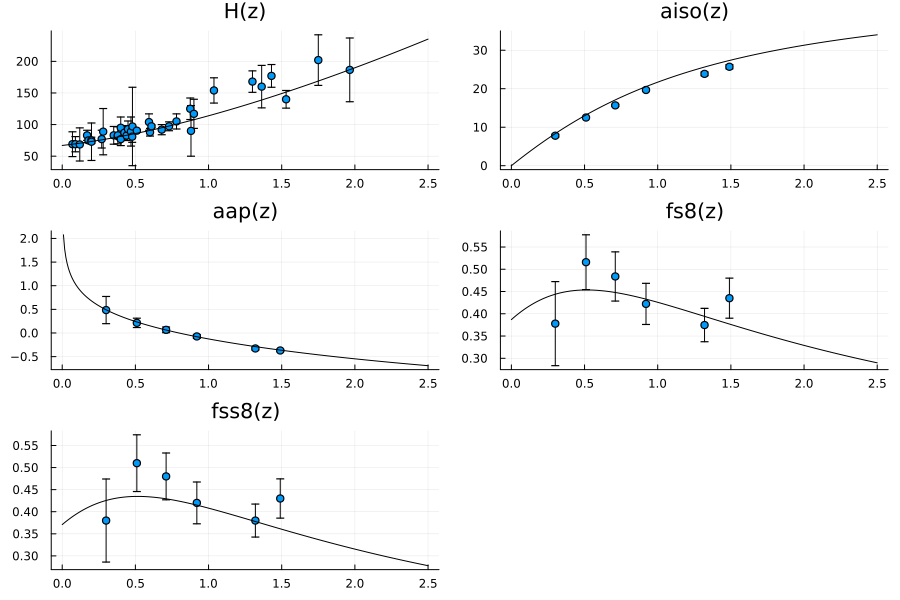

In [28]:
p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,title="H(z)", legend=false)
p1 = plot(dataDESI.z1, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,title="aiso(z)", legend=false)
p2 = plot(dataDESI.z1, log10.(dataDESI.data_dhdm), yerr=aap_err, seriestype=:scatter, title="aap(z)", legend=false)
p3 = plot(datafs8.z, datafs8.data, yerr=fs8_err, seriestype=:scatter, title="fs8(z)", legend=false)
p4 = plot(zdata, fsigma8_data, yerr=fsigma_err, seriestype=:scatter, title="fss8(z)", legend=false)

plot!(p0, z_integ1, hz_from_ez(z_integ1, cosmo1.cpar.h, ez_test), color=:black)
plot!(p1, z_integ1, a_iso(z_integ1, cosmo1.cpar.h, rd_red, ez_test), color=:black)
plot!(p2, z_integ1, log10.(a_ap(z_integ1, cosmo1.cpar.h, ez_test)), color=:black)
plot!(p3, z_integ1, fs8_from_ez(z_integ1, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez_test)[2], color=:black)
plot!(p4, z_integ1, fsigma_s8, color=:black, legend=false)

plot(p0, p1, p2, p3, p4, layout=(3,2), size=(900,600))